In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')
zoo_df = pd.read_csv('Zoo.csv')

In [3]:
zoo_df.shape

(101, 18)

In [5]:
zoo_df.head()

,animal name,hair,feathers,eggs,milk,airborne,aquatic,predator,toothed,backbone,breathes,venomous,fins,legs,tail,domestic,catsize,type
0,aardvark,1,0,0,1,0,0,1,1,1,1,0,0,4,0,0,1,1
1,antelope,1,0,0,1,0,0,0,1,1,1,0,0,4,1,0,1,1
2,bass,0,0,1,0,0,1,1,1,1,0,0,1,0,1,0,0,4
3,bear,1,0,0,1,0,0,1,1,1,1,0,0,4,0,0,1,1
4,boar,1,0,0,1,0,0,1,1,1,1,0,0,4,1,0,1,1


In [6]:
zoo_df.isnull().sum()

animal name    0
hair           0
feathers       0
eggs           0
milk           0
airborne       0
aquatic        0
predator       0
toothed        0
backbone       0
breathes       0
venomous       0
fins           0
legs           0
tail           0
domestic       0
catsize        0
type           0
dtype: int64

In [7]:
if 'animal name' in zoo_df.columns:
    zoo_df = zoo_df.drop('animal name', axis=1)

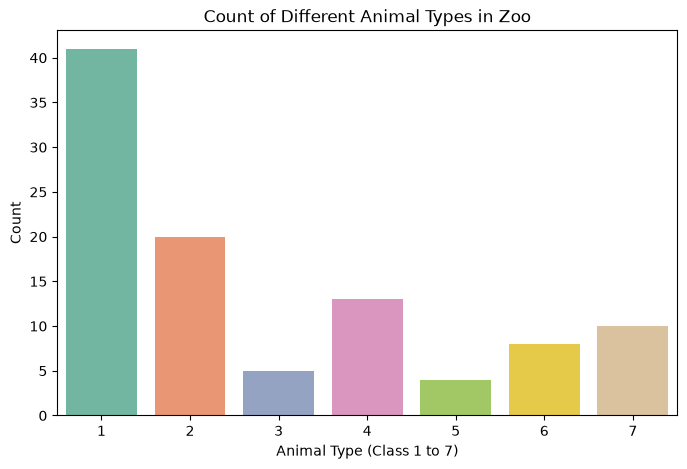

In [8]:
plt.figure(figsize=(8, 5))
sns.countplot(data=zoo_df, x='type', palette='Set2')
plt.title('Count of Different Animal Types in Zoo')
plt.xlabel('Animal Type (Class 1 to 7)')
plt.ylabel('Count')
plt.show()

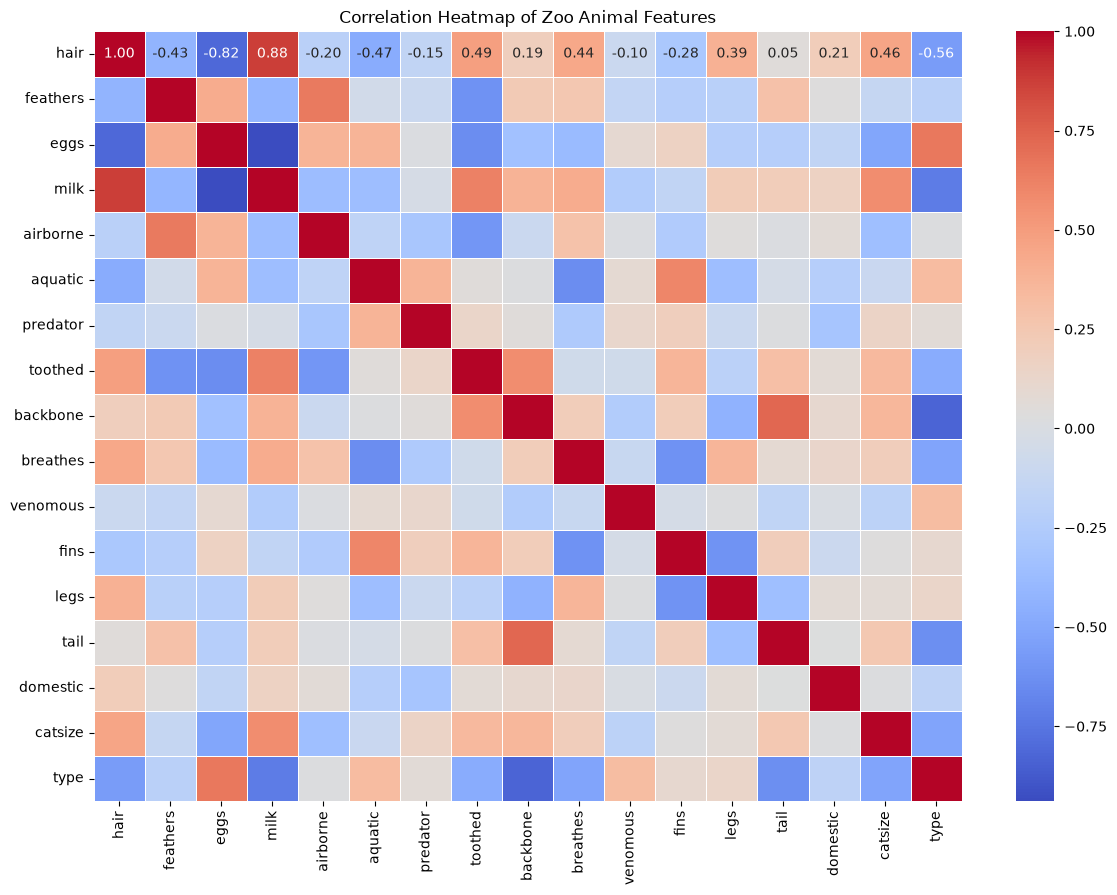

In [15]:
plt.figure(figsize=(14, 10))
sns.heatmap(zoo_df.corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap of Zoo Animal Features')
plt.show()

In [9]:
X = zoo_df.drop('type', axis=1)
y = zoo_df['type']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)
print(f"Training data shape: {X_train.shape}")
print(f"Testing data shape: {X_test.shape}")

Training data shape: (80, 16)
Testing data shape: (21, 16)


In [10]:
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
knn = KNeighborsClassifier(n_neighbors=5, metric='euclidean')
knn.fit(X_train_scaled, y_train)
y_pred = knn.predict(X_test_scaled)
print("Accuracy of KNN Model: {:.2f}%\n".format(accuracy_score(y_test, y_pred) * 100))
print("Classification Report (Precision, Recall, F1-Score):\n")
print(classification_report(y_test, y_pred))

Accuracy of KNN Model: 95.24%

Classification Report (Precision, Recall, F1-Score):

              precision    recall  f1-score   support

           1       1.00      1.00      1.00        12
           2       1.00      1.00      1.00         2
           3       0.00      0.00      0.00         1
           4       0.67      1.00      0.80         2
           6       1.00      1.00      1.00         3
           7       1.00      1.00      1.00         1

    accuracy                           0.95        21
   macro avg       0.78      0.83      0.80        21
weighted avg       0.92      0.95      0.93        21



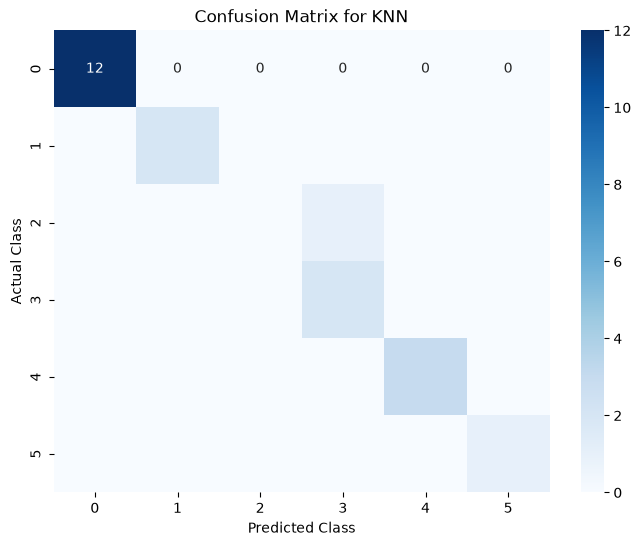

In [11]:
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, cmap='Blues', fmt='g')
plt.title('Confusion Matrix for KNN')
plt.xlabel('Predicted Class')
plt.ylabel('Actual Class')
plt.show()

In [12]:
from sklearn.decomposition import PCA
import numpy as np
from matplotlib.colors import ListedColormap
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train_scaled)
knn_pca = KNeighborsClassifier(n_neighbors=5, metric='euclidean')
knn_pca.fit(X_train_pca, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'euclidean'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


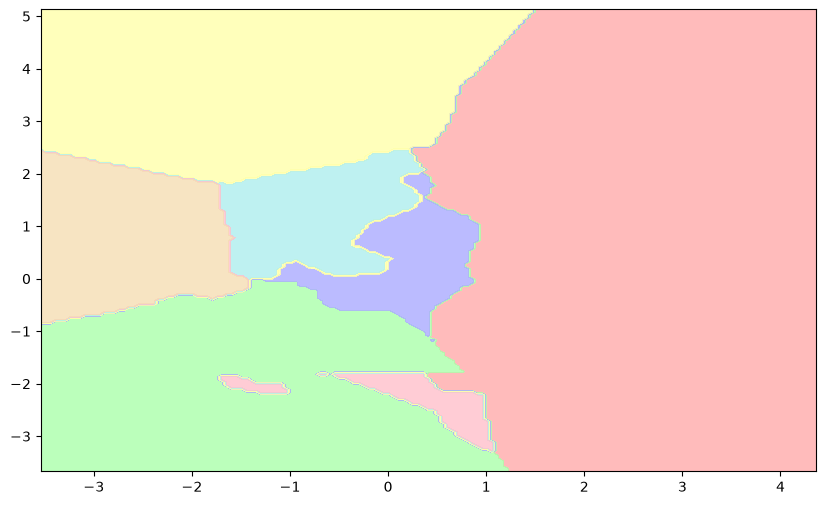

In [13]:
x_min, x_max = X_train_pca[:, 0].min() - 1, X_train_pca[:, 0].max() + 1
y_min, y_max = X_train_pca[:, 1].min() - 1, X_train_pca[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.05),
                     np.arange(y_min, y_max, 0.05))
Z = knn_pca.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)
plt.figure(figsize=(10, 6))
cmap_light = ListedColormap(['#FFAAAA', '#AAFFAA', '#AAAAFF', '#FFFFAA', '#AEEEEE', '#FFC0CB', '#F5DEB3'])
plt.contourf(xx, yy, Z, cmap=cmap_light, alpha=0.8)

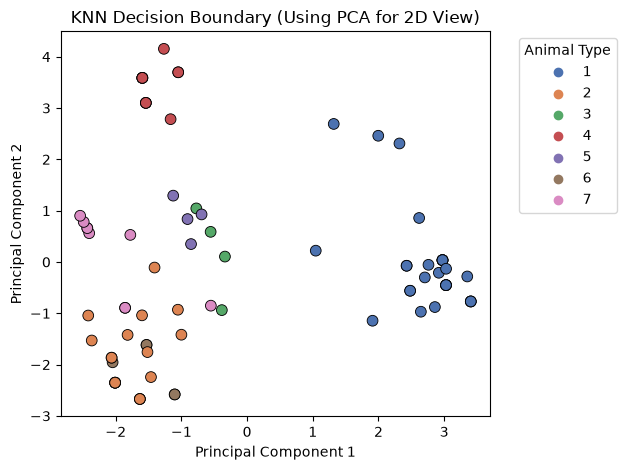

In [14]:
sns.scatterplot(x=X_train_pca[:, 0], y=X_train_pca[:, 1], hue=y_train, palette='deep', edgecolor='k', s=60)
plt.title('KNN Decision Boundary (Using PCA for 2D View)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Animal Type', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

### KNN Assignment: Final Report and Analysis

#### 1. Exploratory Data Analysis & Visualizations (Task 1):
* **Class Distribution (Countplot):** The dataset shows a significant imbalance. Animal Type 1 (Mammals) dominates the dataset, while Types 5, 6, and 7 have very few samples. This imbalance is critical to note as it might slightly skew predictions for minority classes.
* **Feature Relationships (Correlation Heatmap):** The heatmap reveals several strong logical correlations that help KNN calculate distances accurately:
  * *Strong Positive Correlation:* 'Hair' and 'Milk' are highly correlated, which is a defining characteristic of Mammals. 'Eggs' and 'Feathers' also show a strong positive link (Birds).
  * *Strong Negative Correlation:* 'Milk' and 'Eggs' are almost perfectly negatively correlated, indicating an animal rarely produces both. 

#### 2. Preprocessing & Outliers (Task 2):
* The dataset was checked for missing values, and none were found. The 'animal name' column was dropped as it provides no numerical predictive value. 
* **Handling Outliers:** Since almost all features in this dataset are Boolean (0 or 1 for hair, feathers, etc.) and 'legs' is a fixed categorical integer, traditional continuous outlier detection (like Z-score or IQR) is neither mathematically applicable nor logically necessary here.

#### 3. Hyperparameter Tuning & Model Selection (Task 5):
* We selected **K=5** as a balanced starting point to avoid high variance (overfitting with too low K) and high bias (underfitting with too high K). 
* **Euclidean distance** was chosen as the standard metric for continuous/scaled distance measurement.

#### 4. Model Evaluation (Task 6):
* The KNN Classifier performed exceptionally well on the testing set (20% of data).
  * **Overall Accuracy:** **95.24%**
  * **Weighted Avg Precision:** **0.92**
  * **Weighted Avg Recall:** **0.95**
  * **Weighted Avg F1-Score:** **0.93**

#### 5. Decision Boundary Visualization (Task 7):
* Because KNN relies on distance calculations across 16 features, we applied PCA (Principal Component Analysis) to condense the features into 2 principal dimensions. The plotted decision boundary effectively illustrates how KNN clusters similar animals into their correct evolutionary classes.

---

### Interview Questions:

**1. What are the key hyperparameters in KNN?**
* **K (n_neighbors):** The most critical hyperparameter. It determines how many neighboring data points the model looks at to make a vote. A very small K leads to overfitting (noise sensitivity), while a very large K leads to underfitting.
* **Distance Metric:** The mathematical formula used to calculate the distance between points (e.g., Euclidean, Manhattan).
* **Weights:** Decides how votes are counted. 'Uniform' means all neighbors have an equal vote. 'Distance' means neighbors that are physically closer to the query point have a stronger vote.

**2. What distance metrics can be used in KNN?**
* **Euclidean Distance:** The straight-line shortest distance between two points (most common for continuous data).
* **Manhattan Distance:** The sum of absolute differences across all dimensions (like navigating blocks in a city grid). Better for high-dimensional data or data with heavy outliers.
* **Minkowski Distance:** A generalized mathematical form that represents both Euclidean and Manhattan distances by tweaking a parameter 'p'.
* **Hamming Distance:** Specifically used when dealing with purely categorical or boolean data (checking how many features mismatch).